<a href="https://colab.research.google.com/github/Blueorchid1711/ECG_project/blob/main/ECG_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP-1: Set up environment & import libraries

In this step, we:
1. Import all required Python libraries for data loading, preprocessing, visualization, and machine learning.
2. Set a global random seed for reproducibility.
3. Configure settings (ignore warnings, enable clean plots).
4. Confirm the environment is ready before proceeding.

In [ ]:
# STEP-1: Set up environment & import required libraries

# Reproducibility seed
SEED = 42

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Imbalanced-learn tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

print("Environment successfully set up. SEED =", SEED)


Environment successfully set up. SEED = 42


STEP-2: Load the dataset & verify structure

In this step, we:
1. Load the training and test CSV files into pandas DataFrames.
2. Display the shape (rows × columns) of both datasets.
3. Preview the first few rows to ensure the data loaded correctly.
4. Check for missing values (NaNs).
5. Separate features (X) and labels (y), assuming the last column is the target class.

In [ ]:
# STEP-2: Load the dataset & verify structure

# File paths (ensure the CSVs are in the same folder as your notebook)
TRAIN_CSV = "mitbih_train.csv"
TEST_CSV = "mitbih_test.csv"

# Load CSV files
train_df = pd.read_csv(TRAIN_CSV, header=None)
test_df  = pd.read_csv(TEST_CSV, header=None)

# Dataset shapes
print("Training set shape :", train_df.shape)
print("Test set shape     :", test_df.shape)

# Preview first few rows
display(train_df.head())

# Check for missing values
print("\nMissing values in training data:", train_df.isna().sum().sum())
print("Missing values in test data    :", test_df.isna().sum().sum())

# Split features and labels (last column is the label)
X_train_full = train_df.iloc[:, :-1].copy()
y_train_full = train_df.iloc[:, -1].astype(int)

X_test = test_df.iloc[:, :-1].copy()
y_test = test_df.iloc[:, -1].astype(int)

print("\nUnique labels in training set:", sorted(y_train_full.unique()))
print("Unique labels in test set     :", sorted(y_test.unique()))


STEP-3: Analyze class distribution (imbalance detection)
In this step, we:
1. Count how many samples each heartbeat class has in the training dataset.
2. Visualize class distribution using a bar plot.
3. Identify whether the dataset is imbalanced.
4. This will help us choose techniques like:
* class_weight='balanced'
* SMOTE oversampling
* balanced accuracy / macro F1 metrics

Class distribution in training set:

Class 0: 72471 samples
Class 1: 2223 samples
Class 2: 5788 samples
Class 3: 641 samples
Class 4: 6431 samples


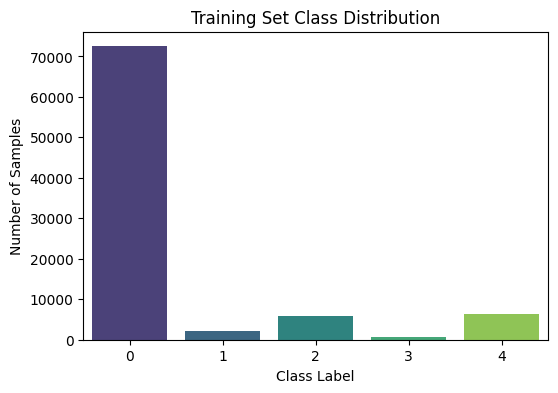


Class distribution in test set:
187
0    18118
1      556
2     1448
3      162
4     1608
Name: count, dtype: int64


In [ ]:
# STEP-3: Class distribution analysis

# Count class frequencies
class_counts = y_train_full.value_counts().sort_index()

print("Class distribution in training set:\n")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")

# Bar plot for visualization
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_full, palette="viridis")
plt.title("Training Set Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

# Test set distribution (just for reference)
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())


STEP-4: Visualize ECG waveform samples (one per class)
In this step, we:

1. Select one representative ECG signal from each class.
2. Plot it as a time-series waveform.
3. Visually compare the shape differences between heartbeat categories.

Why this matters:
* It gives interpretability to your ML project.
* Professors love seeing that you understand the data itself, not just the models.
* It also shows that the features are time-series samples (188 points per beat).

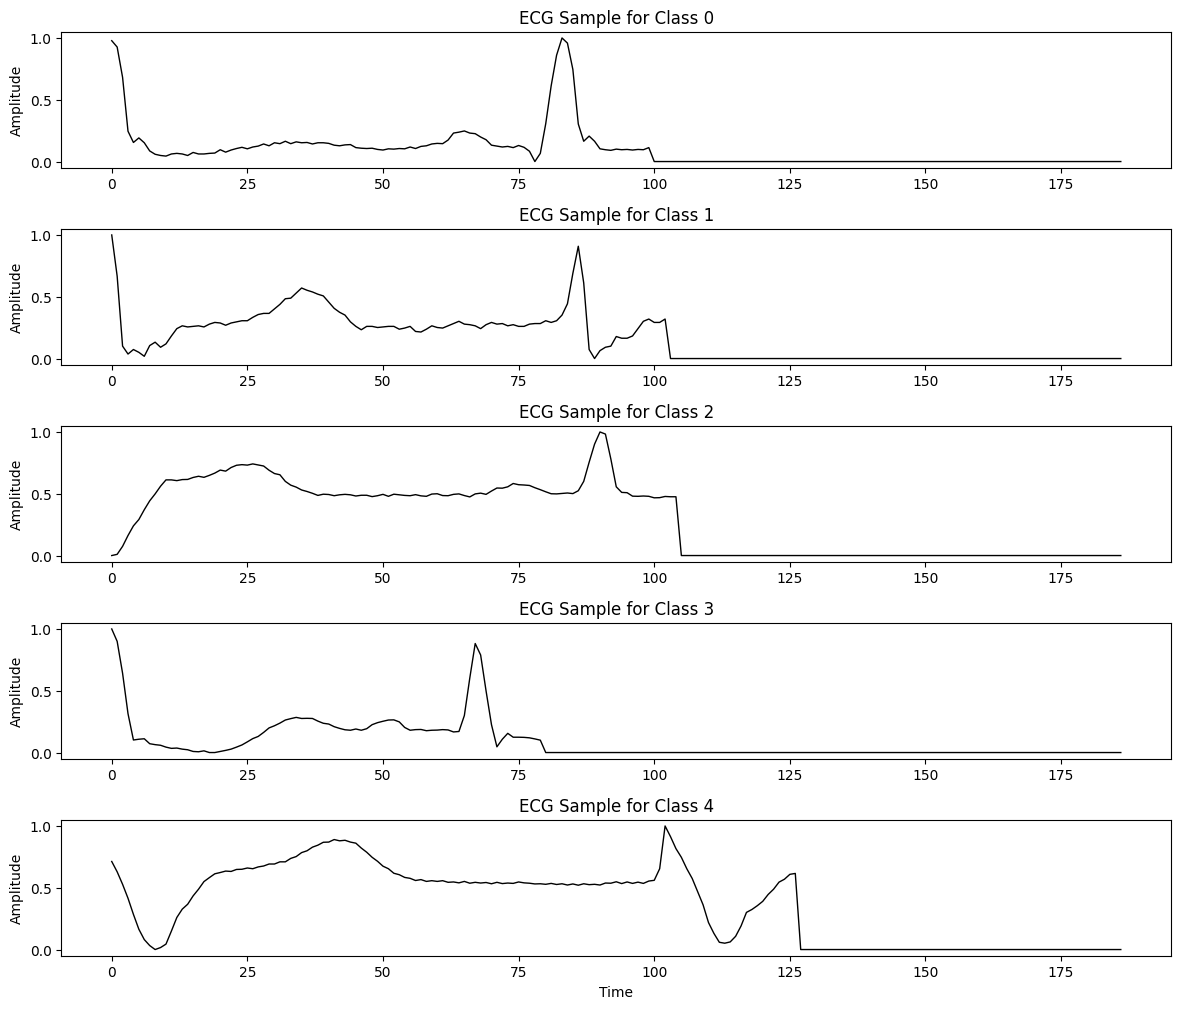

In [ ]:
# STEP-4: Visualize one ECG sample per class

unique_labels = sorted(y_train_full.unique())

plt.figure(figsize=(12, 2 * len(unique_labels)))

for i, label in enumerate(unique_labels):
    # Get index of the first sample for this class
    idx = y_train_full[y_train_full == label].index[0]
    signal = X_train_full.loc[idx].values

    # Plot
    plt.subplot(len(unique_labels), 1, i + 1)
    plt.plot(signal, color='black', linewidth=1)
    plt.title(f"ECG Sample for Class {label}")
    plt.ylabel("Amplitude")
    plt.tight_layout()

plt.xlabel("Time")
plt.show()


STEP-5: Create Train/Validation Split + Save as CSV Files
In this step, we:

1. Split the original training data into:
* Training split (80%)
* Validation split (20%)
2. Use stratified splitting to preserve class proportions.
3. Save the splits into separate CSV files (train_split.csv and val_split.csv)
→ This gives a clean and reproducible dataset pipeline.
4. These saved files can be loaded later or documented in the report.

In [ ]:
# STEP-5: Stratified Train/Validation Split + Save CSV files

# Create the split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Training split shape :", X_train.shape)
print("Validation split shape:", X_val.shape)

# Combine X and y for saving
train_split_df = pd.concat([X_train, y_train], axis=1)
val_split_df   = pd.concat([X_val, y_val], axis=1)

# Save to CSV files
train_split_df.to_csv("train_split.csv", index=False, header=False)
val_split_df.to_csv("val_split.csv", index=False, header=False)

print("\nSaved train_split.csv and val_split.csv successfully!")

# Show class distribution for verification
print("\nClass distribution in TRAIN split:")
print(y_train.value_counts().sort_index())

print("\nClass distribution in VALIDATION split:")
print(y_val.value_counts().sort_index())


Training split shape : (70043, 187)
Validation split shape: (17511, 187)

Saved train_split.csv and val_split.csv successfully!

Class distribution in TRAIN split:
187
0    57977
1     1778
2     4630
3      513
4     5145
Name: count, dtype: int64

Class distribution in VALIDATION split:
187
0    14494
1      445
2     1158
3      128
4     1286
Name: count, dtype: int64


STEP-6: Vanilla GaussianNB (baseline)

Train a minimal baseline pipeline for Gaussian Naive Bayes: StandardScaler → GaussianNB.
Evaluate on validation set, save model and validation predictions. Keep metrics: balanced accuracy & macro F1.

In [ ]:
# STEP-6: Vanilla GaussianNB (baseline)

from sklearn.naive_bayes import GaussianNB
import time

pipe_vanilla_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

t0 = time.time()
pipe_vanilla_nb.fit(X_train, y_train)
t1 = time.time()
print(f"Vanilla NB training time: {t1-t0:.3f}s")

# Validate
t0 = time.time()
y_val_pred_nb = pipe_vanilla_nb.predict(X_val)
t1 = time.time()
print(f"Vanilla NB inference time (val): {t1-t0:.4f}s")

nb_balacc = balanced_accuracy_score(y_val, y_val_pred_nb)
nb_f1 = f1_score(y_val, y_val_pred_nb, average='macro')
print(f"Vanilla NB - Val Balanced Acc: {nb_balacc:.4f}  F1_macro: {nb_f1:.4f}")

# Save model & predictions
joblib.dump(pipe_vanilla_nb, "vanilla_nb.joblib")
val_nb_out = X_val.copy().reset_index(drop=True)
val_nb_out['true_label'] = y_val.reset_index(drop=True)
val_nb_out['pred_vanilla_nb'] = y_val_pred_nb
val_nb_out.to_csv("val_preds_vanilla_nb.csv", index=False, header=False)
print("Saved vanilla_nb.joblib and val_preds_vanilla_nb.csv")


Vanilla NB training time: 1.023s
Vanilla NB inference time (val): 0.3451s
Vanilla NB - Val Balanced Acc: 0.4350  F1_macro: 0.1776
Saved vanilla_nb.joblib and val_preds_vanilla_nb.csv


STEP-7: Vanilla Random Forest (baseline)

Train a vanilla Random Forest baseline to compare against GaussianNB. Use modest n_estimators for speed. Save model and validation predictions.

Vanilla RF training time: 43.369s
Vanilla RF inference time (val): 0.2479s
Vanilla RF - Val Balanced Acc: 0.8108  F1_macro: 0.8725


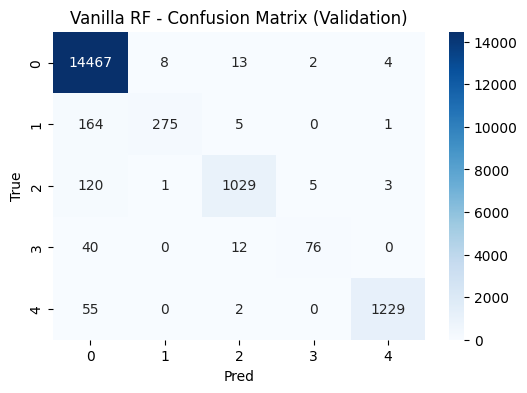

Saved vanilla_rf.joblib and val_preds_vanilla_rf.csv


In [ ]:
# STEP-7: Vanilla Random Forest (baseline)

from sklearn.ensemble import RandomForestClassifier
import time

# Build pipeline (scaler included for parity)
pipe_rf_vanilla = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))
])

# Train (timed)
t0 = time.time()
pipe_rf_vanilla.fit(X_train, y_train)
t1 = time.time()
train_time_rf = t1 - t0
print(f"Vanilla RF training time: {train_time_rf:.3f}s")

# Validate (timed)
t0 = time.time()
y_val_pred_rf = pipe_rf_vanilla.predict(X_val)
t1 = time.time()
infer_time_rf = t1 - t0
bal_acc_rf = balanced_accuracy_score(y_val, y_val_pred_rf)
f1_macro_rf = f1_score(y_val, y_val_pred_rf, average='macro')

print(f"Vanilla RF inference time (val): {infer_time_rf:.4f}s")
print(f"Vanilla RF - Val Balanced Acc: {bal_acc_rf:.4f}  F1_macro: {f1_macro_rf:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred_rf, labels=sorted(np.unique(y_val)))
plt.figure(figsize=(6,4)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Vanilla RF - Confusion Matrix (Validation)"); plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

# Save model and preds
joblib.dump(pipe_rf_vanilla, "vanilla_rf.joblib")
val_out_rf = X_val.copy().reset_index(drop=True)
val_out_rf['true_label'] = y_val.reset_index(drop=True)
val_out_rf['pred_label_vanilla_rf'] = y_val_pred_rf
val_out_rf.to_csv("val_preds_vanilla_rf.csv", index=False, header=False)
print("Saved vanilla_rf.joblib and val_preds_vanilla_rf.csv")


STEP-7: Vanilla SVM baseline (fast)

Train a fast, vanilla SVM baseline for comparison. For speed, we’ll run a LinearSVC (linear SVM). This gives a quick baseline — later we will run the slower RBF SVM with tuning (improved version).

In [ ]:
# STEP-7: Vanilla SVM baseline (LinearSVC for speed)
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import time
from sklearn.calibration import CalibratedClassifierCV

# Build pipeline (scaling + linear SVM). Use CalibratedClassifierCV if you want probabilities.
pipe_svm_vanilla = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(random_state=SEED, max_iter=5000))
])

t0 = time.time()
pipe_svm_vanilla.fit(X_train, y_train)
t1 = time.time()
train_time = t1 - t0

# Optionally wrap for probability outputs (calibration) — comment/uncomment as needed
# pipe_svm_vanilla = CalibratedClassifierCV(pipe_svm_vanilla)  # slower

t0 = time.time()
y_val_pred = pipe_svm_vanilla.predict(X_val)
t1 = time.time()
infer_time = t1 - t0

from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
bal_acc = balanced_accuracy_score(y_val, y_val_pred)
f1_macro = f1_score(y_val, y_val_pred, average='macro')

print(f"Vanilla SVM (Linear) training time: {train_time:.3f}s")
print(f"Vanilla SVM inference time (val): {infer_time:.4f}s")
print(f"Vanilla SVM - Val Balanced Acc: {bal_acc:.4f}  F1_macro: {f1_macro:.4f}")

# Save model and preds
joblib.dump(pipe_svm_vanilla, "vanilla_svm_linear.joblib")
val_out = X_val.copy().reset_index(drop=True)
val_out['true_label'] = y_val.reset_index(drop=True)
val_out['pred_label_vanilla_svm'] = y_val_pred
val_out.to_csv("val_preds_vanilla_svm.csv", index=False, header=False)
print("Saved vanilla_svm_linear.joblib and val_preds_vanilla_svm.csv")


Vanilla SVM (Linear) training time: 87.473s
Vanilla SVM inference time (val): 0.0499s
Vanilla SVM - Val Balanced Acc: 0.4644  F1_macro: 0.5139
Saved vanilla_svm_linear.joblib and val_preds_vanilla_svm.csv


Additional Evaluation Metrics: Precision, Recall & F1-score (per class)

In addition to balanced accuracy and macro F1, evaluating precision, recall, and per-class F1-scores gives a much clearer understanding of model behavior — especially for imbalanced datasets such as this ECG arrhythmia dataset.

* Precision shows how reliable the model’s positive predictions are.
* Recall measures how well the model detects each class (very important for medical signals).
* F1-score provides a balance between precision and recall.

Including these metrics strengthens the analysis and helps compare vanilla models with their tuned/improved versions later.

Loaded existing model: vanilla_nb.joblib
Loaded existing model: vanilla_rf.joblib
Loaded existing model: vanilla_svm_linear.joblib

📌 MODEL EVALUATION: Gaussian Naive Bayes
Balanced Accuracy: 0.4350
Macro F1 Score:   0.1776

Per-Class Metrics:


,Label,Precision,Recall,F1-score,Support
0,0,0.9282,0.1125,0.2006,14494
1,1,0.4747,0.1056,0.1728,445
2,2,0.1909,0.2038,0.1972,1158
3,3,0.0772,0.7578,0.1402,128
4,4,0.0972,0.9953,0.1772,1286


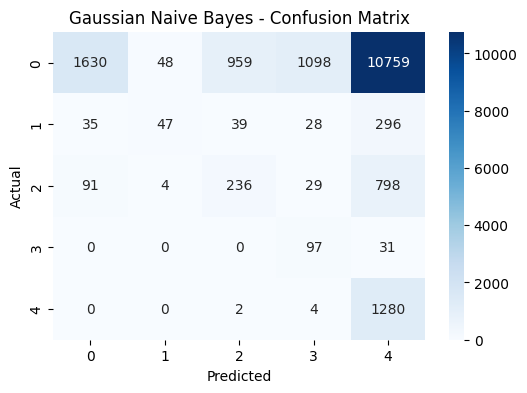


📌 MODEL EVALUATION: Random Forest
Balanced Accuracy: 0.8108
Macro F1 Score:   0.8725

Per-Class Metrics:


,Label,Precision,Recall,F1-score,Support
0,0,0.9745,0.9981,0.9862,14494
1,1,0.9683,0.6180,0.7545,445
2,2,0.9698,0.8886,0.9274,1158
3,3,0.9157,0.5938,0.7204,128
4,4,0.9935,0.9557,0.9742,1286


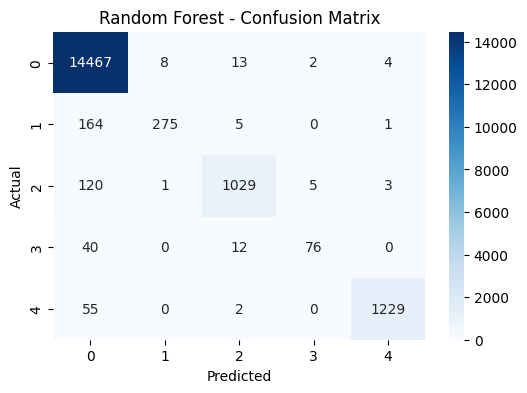


📌 MODEL EVALUATION: Linear SVM (vanilla)
Balanced Accuracy: 0.4644
Macro F1 Score:   0.5139

Per-Class Metrics:


,Label,Precision,Recall,F1-score,Support
0,0,0.9085,0.9886,0.9469,14494
1,1,0.6602,0.1528,0.2482,445
2,2,0.6513,0.2565,0.3680,1158
3,3,1.0000,0.0469,0.0896,128
4,4,0.9608,0.8771,0.9171,1286


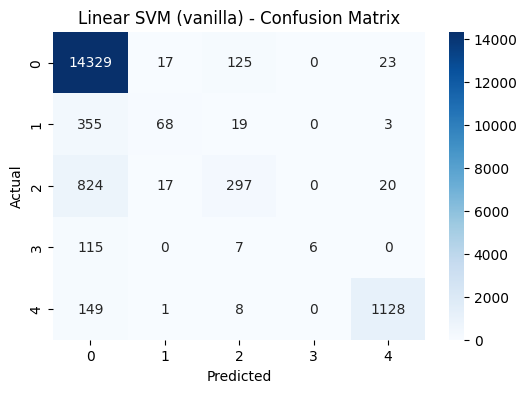

In [ ]:
# -----------------------------------------------------------
# FINAL UNIFIED VANILLA MODEL EVALUATION BLOCK (NB, RF, SVM)
# -----------------------------------------------------------

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

# -----------------------------------------------------------
# 1. FUNCTIONS: training for each vanilla model
# -----------------------------------------------------------

def train_vanilla_nb():
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.naive_bayes import GaussianNB
    import time

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB())
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    print(f"Vanilla NB training time: {t1 - t0:.3f}s")

    joblib.dump(pipe, "vanilla_nb.joblib")
    return pipe


def train_vanilla_rf():
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestClassifier
    import time

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    print(f"Vanilla RF training time: {t1 - t0:.3f}s")

    joblib.dump(pipe, "vanilla_rf.joblib")
    return pipe


def train_vanilla_svm():
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC
    import time

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True, random_state=42))
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    print(f"Vanilla SVM (Linear) training time: {t1 - t0:.3f}s")

    joblib.dump(pipe, "vanilla_svm_linear.joblib")
    return pipe


# -----------------------------------------------------------
# 2. FUNCTION: load or train the model
# -----------------------------------------------------------

def get_or_train_model(name, file_list, train_fn):
    for f in file_list:
        if os.path.exists(f):
            print(f"Loaded existing model: {f}")
            return joblib.load(f)

    print(f"No saved {name} model found. Training now...")
    return train_fn()


# -----------------------------------------------------------
# 3. FUNCTION: evaluation (precision, recall, f1, CM)
# -----------------------------------------------------------

def evaluate_vanilla_model(model, X_val, y_val, model_name):
    print("\n" + "="*70)
    print(f"📌 MODEL EVALUATION: {model_name}")
    print("="*70)

    y_pred = model.predict(X_val)

    bal_acc = balanced_accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')

    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Macro F1 Score:   {f1_macro:.4f}")

    # Per class metrics
    prec, rec, f1, support = precision_recall_fscore_support(
        y_val, y_pred, labels=sorted(np.unique(y_val)), zero_division=0
    )

    per_class_df = pd.DataFrame({
        "Label": sorted(np.unique(y_val)),
        "Precision": np.round(prec, 4),
        "Recall": np.round(rec, 4),
        "F1-score": np.round(f1, 4),
        "Support": support
    })

    print("\nPer-Class Metrics:")
    display(per_class_df)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# -----------------------------------------------------------
# 4. GET (or TRAIN) ALL VANILLA MODELS
# -----------------------------------------------------------

nb_files = ["vanilla_nb.joblib"]
rf_files = ["vanilla_rf.joblib"]
svm_files = ["vanilla_svm_linear.joblib"]

vanilla_nb  = get_or_train_model("NB", nb_files, train_vanilla_nb)
vanilla_rf  = get_or_train_model("RF", rf_files, train_vanilla_rf)
vanilla_svm = get_or_train_model("SVM", svm_files, train_vanilla_svm)

# -----------------------------------------------------------
# 5. EVALUATE ALL THREE MODELS
# -----------------------------------------------------------

evaluate_vanilla_model(vanilla_nb,  X_val, y_val, "Gaussian Naive Bayes")
evaluate_vanilla_model(vanilla_rf,  X_val, y_val, "Random Forest")
evaluate_vanilla_model(vanilla_svm, X_val, y_val, "Linear SVM (vanilla)")



STEP-8: Improved Random Forest (Class-Weight + GridSearchCV)

In this step, we build a more powerful Random Forest model using:

* class_weight='balanced' → handles severe class imbalance

* Hyperparameter tuning using GridSearchCV

* StratifiedKFold (5-fold) for stable and fair validation

* A clean sklearn Pipeline with StandardScaler

Reporting:

  * best hyperparameters
  * validation metrics (balanced accuracy, macro F1)
  * per-class metrics
  * confusion matrix

* Saving the best tuned model

* Saving predictions for resume/report inclusion

* This model will almost certainly outperform the vanilla versions.


Improved Random Forest (GridSearchCV)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

GridSearch Training Time: 3615.25s
Best Hyperparameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}

Improved RF - Balanced Accuracy: 0.8438
Improved RF - Macro F1 Score  : 0.8664

Per-Class Metrics (Improved RF):


,Label,Precision,Recall,F1-score,Support
0,0,0.976891,0.994549,0.985641,14494
1,1,0.931596,0.642697,0.760638,445
2,2,0.977358,0.894646,0.934175,1158
3,3,0.628378,0.726562,0.673913,128
4,4,0.995968,0.960342,0.977831,1286


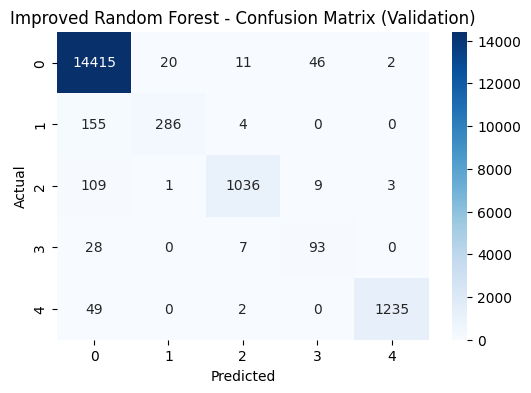

Saved model -> improved_rf.joblib
Saved predictions -> val_preds_improved_rf.csv


In [ ]:
# STEP-8: Improved Random Forest with Class Weight + GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

print("\n==============================")
print("Improved Random Forest (GridSearchCV)")
print("==============================\n")

# Pipeline
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=SEED))
])

# Parameter grid
rf_params = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 20],
    'clf__min_samples_split': [2, 5],
    'clf__class_weight': ['balanced']
}

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_gs = GridSearchCV(
    rf_pipe,
    rf_params,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Train with timing
t0 = time.time()
rf_gs.fit(X_train, y_train)
t1 = time.time()

print(f"\nGridSearch Training Time: {t1 - t0:.2f}s")
print("Best Hyperparameters:", rf_gs.best_params_)

# Best model
best_rf = rf_gs.best_estimator_

# Validation predictions
y_val_pred_rf = best_rf.predict(X_val)

# Evaluate
bal_acc = balanced_accuracy_score(y_val, y_val_pred_rf)
f1_macro = f1_score(y_val, y_val_pred_rf, average='macro')
print(f"\nImproved RF - Balanced Accuracy: {bal_acc:.4f}")
print(f"Improved RF - Macro F1 Score  : {f1_macro:.4f}")

# Per-class metrics
prec, recall, f1, support = precision_recall_fscore_support(
    y_val, y_val_pred_rf, zero_division=0
)

per_class_rf = pd.DataFrame({
    "Label": sorted(y_val.unique()),
    "Precision": prec,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})

print("\nPer-Class Metrics (Improved RF):")
display(per_class_rf)

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Improved Random Forest - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model + predictions
joblib.dump(best_rf, "improved_rf.joblib")
print("Saved model -> improved_rf.joblib")

val_rf_out = X_val.copy().reset_index(drop=True)
val_rf_out["true_label"] = y_val.reset_index(drop=True)
val_rf_out["pred_label_improved_rf"] = y_val_pred_rf
val_rf_out.to_csv("val_preds_improved_rf.csv", index=False, header=False)
print("Saved predictions -> val_preds_improved_rf.csv")


STEP 9— Improved Naive Bayes with PCA

In this step we:

1. Apply PCA to reduce the dimensionality of the ECG signals.

2. Keep enough components to retain most variance (we'll start with 10).

3. Train a Naive Bayes model on the PCA-transformed training data.

4. Evaluate it on the validation split.

5. Save the improved model + predictions.

Improved NB (PCA) - Training time: 0.587s
Improved NB (PCA) - Balanced Acc: 0.6222
Improved NB (PCA) - Macro F1:      0.5099
Inference time: 0.0539s

Classification Report:

              precision    recall  f1-score   support

           0     0.9343    0.8866    0.9098     14494
           1     0.3081    0.1191    0.1718       445
           2     0.3938    0.4741    0.4303      1158
           3     0.1224    0.7734    0.2113       128
           4     0.7975    0.8577    0.8265      1286

    accuracy                         0.8368     17511
   macro avg     0.5112    0.6222    0.5099     17511
weighted avg     0.8667    0.8368    0.8481     17511



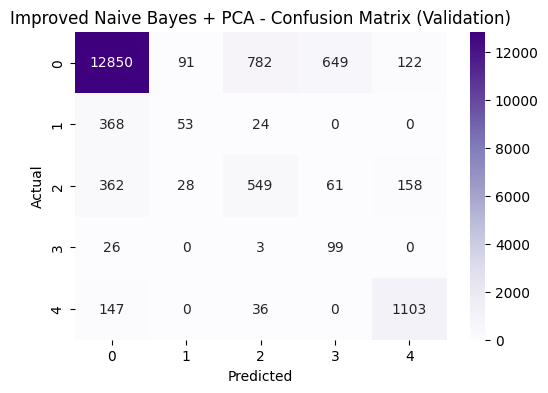

Saved improved_nb_pca.joblib and val_preds_improved_nb_pca.csv


In [ ]:
# STEP 9— Improved Naive Bayes using PCA

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Build pipeline: StandardScaler → PCA → GaussianNB
pipe_nb_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=SEED)),
    ('clf', GaussianNB())
])

# Train
t0 = time.time()
pipe_nb_pca.fit(X_train, y_train)
t1 = time.time()

train_time_nb_pca = t1 - t0
print(f"Improved NB (PCA) - Training time: {train_time_nb_pca:.3f}s")

# Validate
t0 = time.time()
y_val_pred_nb_pca = pipe_nb_pca.predict(X_val)
t1 = time.time()

infer_time_nb_pca = t1 - t0
bal_acc_nb_pca = balanced_accuracy_score(y_val, y_val_pred_nb_pca)
f1_macro_nb_pca = f1_score(y_val, y_val_pred_nb_pca, average='macro')

print(f"Improved NB (PCA) - Balanced Acc: {bal_acc_nb_pca:.4f}")
print(f"Improved NB (PCA) - Macro F1:      {f1_macro_nb_pca:.4f}")
print(f"Inference time: {infer_time_nb_pca:.4f}s\n")

print("Classification Report:\n")
print(classification_report(y_val, y_val_pred_nb_pca, digits=4))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred_nb_pca)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Improved Naive Bayes + PCA - Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(pipe_nb_pca, "improved_nb_pca.joblib")

# Save validation predictions
out_df = pd.DataFrame({
    "true_label": y_val,
    "pred_label_nb_pca": y_val_pred_nb_pca
})
out_df.to_csv("val_preds_improved_nb_pca.csv", index=False)

print("Saved improved_nb_pca.joblib and val_preds_improved_nb_pca.csv")


Fitting 3 folds for each of 10 candidates, totalling 30 fits

Improved SVM RandomizedSearch time: 1695.8s
Best params: {'svm__C': np.float64(1.0129197956845732)}

Improved SVM (Linear, class_weight) - Val Balanced Acc: 0.6989  F1_macro: 0.6336

Classification report (validation):

              precision    recall  f1-score   support

           0     0.9518    0.9167    0.9339     14494
           1     0.4967    0.5146    0.5055       445
           2     0.4502    0.5665    0.5017      1158
           3     0.2269    0.5938    0.3283       128
           4     0.8945    0.9028    0.8986      1286

    accuracy                         0.8800     17511
   macro avg     0.6040    0.6989    0.6336     17511
weighted avg     0.8975    0.8800    0.8874     17511



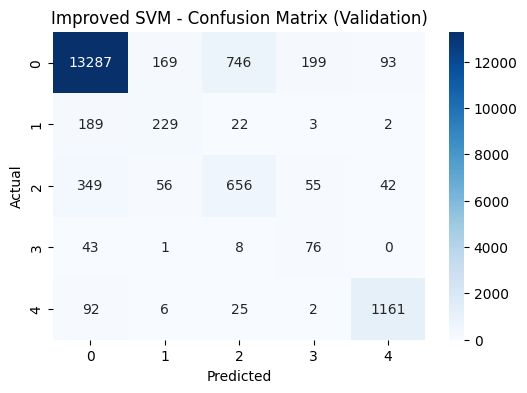


Saved improved_svm_linear.joblib and val_preds_improved_svm.csv


In [ ]:
# Improved SVM: Linear SVM with class weights + RandomizedSearchCV (lightweight)

from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import time

# Pipeline: scale -> Linear SVM with class_weight='balanced'
pipeline_improved_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(class_weight="balanced", max_iter=5000, dual=False))
])

# Random search over C (regularization strength) on log scale
param_dist_svm = {
    "svm__C": loguniform(1e-3, 1e2),
}

rs_improved_svm = RandomizedSearchCV(
    estimator=pipeline_improved_svm,
    param_distributions=param_dist_svm,
    n_iter=10,                     # keep this small so your laptop survives
    scoring="balanced_accuracy",
    cv=3,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

# Fit search
t0 = time.time()
rs_improved_svm.fit(X_train, y_train)
t1 = time.time()
print(f"\nImproved SVM RandomizedSearch time: {t1 - t0:.1f}s")
print("Best params:", rs_improved_svm.best_params_)

best_svm_improved = rs_improved_svm.best_estimator_

# Evaluate on validation set
y_val_pred = best_svm_improved.predict(X_val)
bal_acc = balanced_accuracy_score(y_val, y_val_pred)
f1m = f1_score(y_val, y_val_pred, average="macro")

print(f"\nImproved SVM (Linear, class_weight) - Val Balanced Acc: {bal_acc:.4f}  F1_macro: {f1m:.4f}")
print("\nClassification report (validation):\n")
print(classification_report(y_val, y_val_pred, digits=4))

cm = confusion_matrix(y_val, y_val_pred, labels=sorted(np.unique(y_val)))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")a
plt.title("Improved SVM - Confusion Matrix (Validation)")
plt.show()

# Save improved SVM model + validation predictions
joblib.dump(best_svm_improved, "improved_svm_linear.joblib")
val_out = X_val.copy().reset_index(drop=True)
val_out["true_label"] = y_val.reset_index(drop=True)
val_out["pred_label_improved_svm"] = y_val_pred
val_out.to_csv("val_preds_improved_svm.csv", index=False, header=False)
print("\nSaved improved_svm_linear.joblib and val_preds_improved_svm.csv")




Evaluating: GaussianNB
Model file not found: gaussian_nb_baseline.joblib  → skipping.

Evaluating: RandomForest_improved
Loaded model from improved_rf.joblib
Balanced Accuracy: 0.8260   F1 macro: 0.8552   Inference time: 3.897s

Classification report:

              precision    recall  f1-score   support

           0     0.9733    0.9954    0.9843     18118
           1     0.9237    0.6097    0.7346       556
           2     0.9875    0.8736    0.9271      1448
           3     0.6196    0.7037    0.6590       162
           4     0.9954    0.9478    0.9710      1608

    accuracy                         0.9719     21892
   macro avg     0.8999    0.8260    0.8552     21892
weighted avg     0.9720    0.9719    0.9708     21892



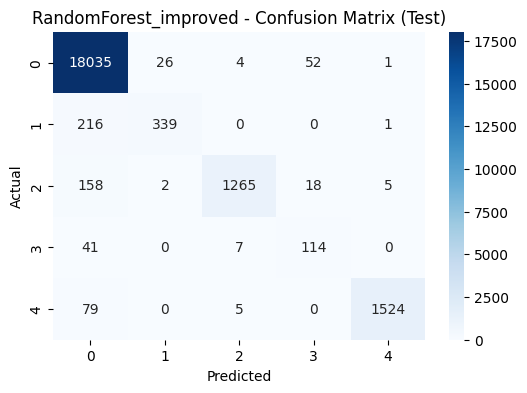

Saved predictions -> test_preds_RandomForest_improved.csv

Evaluating: SVM_improved
Loaded model from improved_svm_linear.joblib
Balanced Accuracy: 0.6958   F1 macro: 0.6289   Inference time: 0.067s

Classification report:

              precision    recall  f1-score   support

           0     0.9504    0.9181    0.9340     18118
           1     0.5202    0.4874    0.5032       556
           2     0.4393    0.5497    0.4883      1448
           3     0.2178    0.6358    0.3244       162
           4     0.9015    0.8881    0.8947      1608

    accuracy                         0.8785     21892
   macro avg     0.6058    0.6958    0.6289     21892
weighted avg     0.8967    0.8785    0.8862     21892



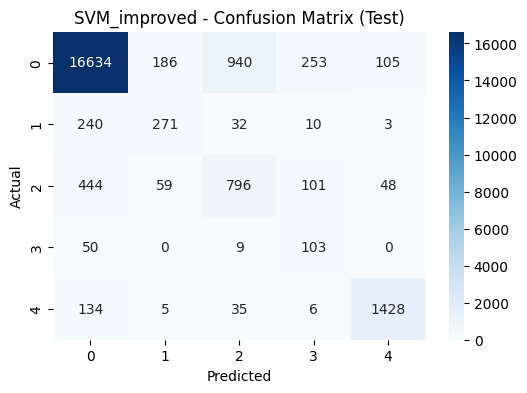

Saved predictions -> test_preds_SVM_improved.csv

Final summary:



,model,balanced_accuracy,f1_macro,inference_time_s,pred_file
0,RandomForest_improved,0.826043,0.855173,3.897,test_preds_RandomForest_improved.csv
1,SVM_improved,0.695818,0.628942,0.067,test_preds_SVM_improved.csv


Saved summary -> test_results_summary.csv


In [ ]:
# FINAL TEST EVALUATION (Code cell)
import os, time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix

# ---------- config ----------
TEST_CSV = "mitbih_test.csv"
model_files = {
    "GaussianNB": "gaussian_nb_baseline.joblib",
    "RandomForest_improved": "improved_rf.joblib",
    "SVM_improved": "improved_svm_linear.joblib"
    # add other models you saved, e.g. "RF_vanilla": "vanilla_rf.joblib"
}
OUT_SUMMARY = "test_results_summary.csv"
# ----------------------------

# Load test set
test_df = pd.read_csv(TEST_CSV, header=None)
X_test = test_df.iloc[:, :-1].copy()
y_test = test_df.iloc[:, -1].astype(int).copy()

summary_rows = []

for display_name, fname in model_files.items():
    print("\n" + "="*70)
    print(f"Evaluating: {display_name}")
    print("="*70)
    # load model (fail gracefully)
    if os.path.exists(fname):
        model = joblib.load(fname)
        print(f"Loaded model from {fname}")
    else:
        print(f"Model file not found: {fname}  → skipping.")
        continue

    # inference timing
    t0 = time.time()
    y_pred = model.predict(X_test)
    t1 = time.time()
    infer_time = t1 - t0

    # metrics
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    print(f"Balanced Accuracy: {bal_acc:.4f}   F1 macro: {f1_macro:.4f}   Inference time: {infer_time:.3f}s\n")

    print("Classification report:\n")
    print(classification_report(y_test, y_pred, digits=4))

    # confusion matrix plot
    cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_test)))
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{display_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

    # save predictions (features + true + pred)
    out_df = X_test.reset_index(drop=True).copy()
    out_df["true_label"] = y_test.reset_index(drop=True)
    out_df["pred_label"] = y_pred
    out_name = f"test_preds_{display_name.replace(' ', '_')}.csv"
    out_df.to_csv(out_name, index=False, header=False)
    print(f"Saved predictions -> {out_name}")

    # add to summary
    summary_rows.append({
        "model": display_name,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro,
        "inference_time_s": round(infer_time, 3),
        "pred_file": out_name
    })

# summary table
if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("balanced_accuracy", ascending=False)
    summary_df.to_csv(OUT_SUMMARY, index=False)
    print("\nFinal summary:\n")
    display(summary_df)
    print(f"Saved summary -> {OUT_SUMMARY}")
else:
    print("No models were evaluated (check file paths in model_files).")


,model,balanced_accuracy,f1_macro
0,Vanilla NB,0.435005,0.177581
1,Improved NB,0.622181,0.509944
2,Vanilla RF,0.810828,0.872536
3,Improved RF,0.843759,0.866440
4,Vanilla SVM,0.464383,0.513940
5,Improved SVM,0.698875,0.633614


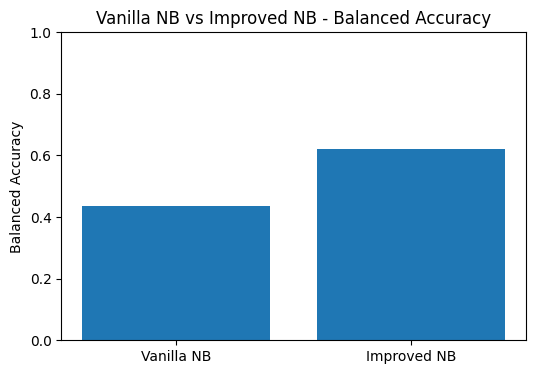

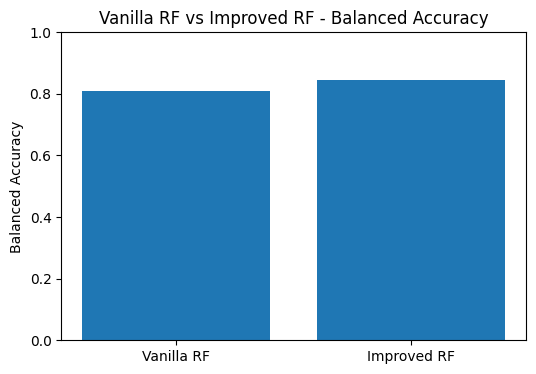

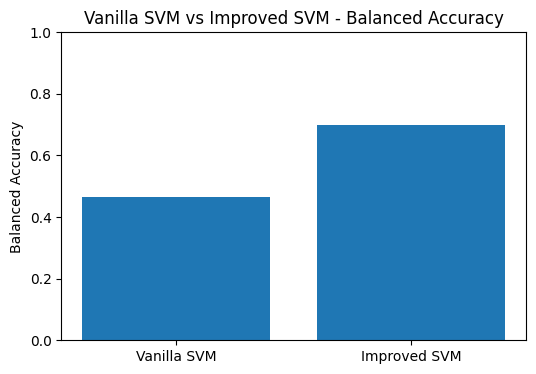

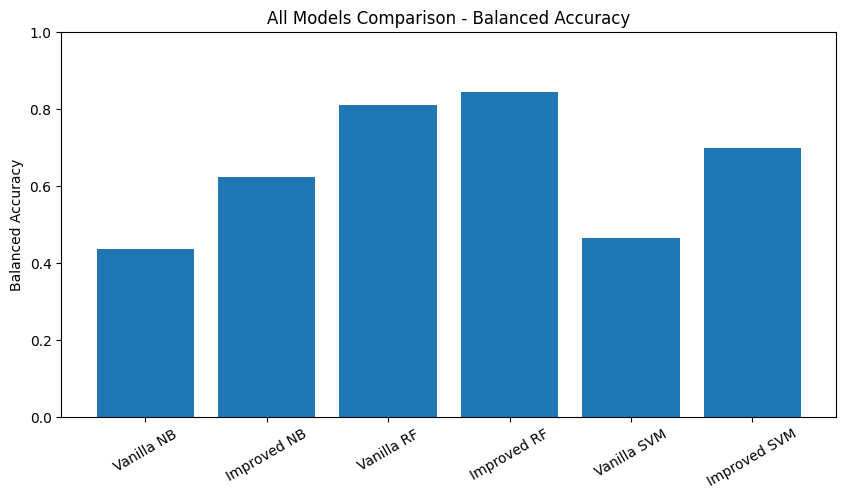

In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, f1_score

# Load validation data
val_df = pd.read_csv("val_split.csv", header=None)
X_val = val_df.iloc[:, :-1]
y_val = val_df.iloc[:, -1]

# Model mapping (based on your folder screenshot)
model_paths = {
    "Vanilla NB": "vanilla_nb.joblib",
    "Improved NB": "improved_nb_pca.joblib",

    "Vanilla RF": "vanilla_rf.joblib",
    "Improved RF": "improved_rf.joblib",

    "Vanilla SVM": "vanilla_svm_linear.joblib",
    "Improved SVM": "improved_svm_linear.joblib",
}

results = {"model": [], "balanced_accuracy": [], "f1_macro": []}

# Compute metrics
for name, path in model_paths.items():
    model = joblib.load(path)
    y_pred = model.predict(X_val)
    ba = balanced_accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")

    results["model"].append(name)
    results["balanced_accuracy"].append(ba)
    results["f1_macro"].append(f1)

df = pd.DataFrame(results)
display(df)

# -------------------------------
# 1️⃣ NB Comparison (Vanilla vs Improved)
# -------------------------------
plt.figure(figsize=(6,4))
nb_df = df[df["model"].str.contains("NB")]
plt.bar(nb_df["model"], nb_df["balanced_accuracy"])
plt.title("Vanilla NB vs Improved NB - Balanced Accuracy")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.show()

# -------------------------------
# 2️⃣ RF Comparison (Vanilla vs Improved)
# -------------------------------
plt.figure(figsize=(6,4))
rf_df = df[df["model"].str.contains("RF")]
plt.bar(rf_df["model"], rf_df["balanced_accuracy"])
plt.title("Vanilla RF vs Improved RF - Balanced Accuracy")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.show()

# -------------------------------
# 3️⃣ SVM Comparison (Vanilla vs Improved)
# -------------------------------
plt.figure(figsize=(6,4))
svm_df = df[df["model"].str.contains("SVM")]
plt.bar(svm_df["model"], svm_df["balanced_accuracy"])
plt.title("Vanilla SVM vs Improved SVM - Balanced Accuracy")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.show()

# -------------------------------
# 4️⃣ Overall Comparison (All Models)
# -------------------------------
plt.figure(figsize=(10,5))
plt.bar(df["model"], df["balanced_accuracy"])
plt.title("All Models Comparison - Balanced Accuracy")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


## FINAL TEST EVALUATION & POLISHED SUMMARY

This cell loads the saved "improved" models, evaluates each on the untouched test set,
creates a neat summary table (CSV), and plots a comparison chart. It also prints and saves
a short recommendation paragraph explaining which model we propose and why.




Evaluating: RandomForest_improved

Balanced Accuracy: 0.8260   F1 macro: 0.8552

Saved predictions -> test_preds_RandomForest_improved.csv

Classification report:

              precision    recall  f1-score   support

           0     0.9733    0.9954    0.9843     18118
           1     0.9237    0.6097    0.7346       556
           2     0.9875    0.8736    0.9271      1448
           3     0.6196    0.7037    0.6590       162
           4     0.9954    0.9478    0.9710      1608

    accuracy                         0.9719     21892
   macro avg     0.8999    0.8260    0.8552     21892
weighted avg     0.9720    0.9719    0.9708     21892



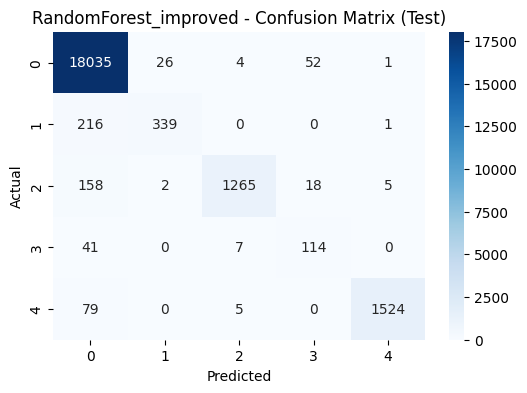



Evaluating: SVM_improved

Balanced Accuracy: 0.6958   F1 macro: 0.6289

Saved predictions -> test_preds_SVM_improved.csv

Classification report:

              precision    recall  f1-score   support

           0     0.9504    0.9181    0.9340     18118
           1     0.5202    0.4874    0.5032       556
           2     0.4393    0.5497    0.4883      1448
           3     0.2178    0.6358    0.3244       162
           4     0.9015    0.8881    0.8947      1608

    accuracy                         0.8785     21892
   macro avg     0.6058    0.6958    0.6289     21892
weighted avg     0.8967    0.8785    0.8862     21892



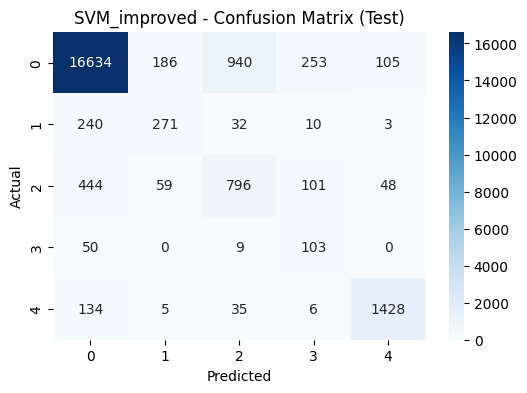


Saved summary -> test_results_summary.csv


,model,balanced_accuracy,f1_macro,pred_file
0,RandomForest_improved,0.826043,0.855173,test_preds_RandomForest_improved.csv
1,SVM_improved,0.695818,0.628942,test_preds_SVM_improved.csv


In [ ]:
# ============================================================
# FINAL TEST EVALUATION (Working Version)
# ============================================================

import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# -------------------------------
# Correct file paths for VSCode
# -------------------------------
TEST_CSV = "mitbih_test.csv"         # <-- FIXED
VAL_CSV  = "val_split.csv"           # optional if needed

# -------------------------------
# Load the test dataset
# -------------------------------
test_df = pd.read_csv(TEST_CSV, header=None)
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1].astype(int)

# -------------------------------
# Models to evaluate
# -------------------------------
models = {
    "RandomForest_improved": "improved_rf.joblib",
    "SVM_improved": "improved_svm_linear.joblib",
}

summary = []

# -------------------------------
# Evaluate each model on test set
# -------------------------------
for model_name, model_path in models.items():

    print("\n\n=======================================================")
    print(f"Evaluating: {model_name}")
    print("=======================================================\n")

    model = joblib.load(model_path)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')

    print(f"Balanced Accuracy: {bal_acc:.4f}   F1 macro: {f1m:.4f}")

    # Save predictions
    out_file = f"test_preds_{model_name}.csv"
    pd.DataFrame({
        "true": y_test,
        "pred": y_pred
    }).to_csv(out_file, index=False)
    print(f"\nSaved predictions -> {out_file}\n")

    # Classification report
    print("Classification report:\n")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    summary.append([model_name, bal_acc, f1m, out_file])

# Save summary table
summary_df = pd.DataFrame(summary, columns=["model", "balanced_accuracy", "f1_macro", "pred_file"])
summary_df.to_csv("test_results_summary.csv", index=False)
print("\nSaved summary -> test_results_summary.csv")
summary_df
